Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,classification_report, confusion_matrix)

Load Data

In [2]:
df = pd.read_csv('cloud_outages_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (50000, 40)


,incident_id,cloud_provider,region,service,service_subtype,start_time,end_time,duration_minutes,severity,status,...,post_mortem_link,is_recurrent_issue,previous_incident_id,external_factors,scheduled_maintenance_conflict,patch_applied,system_load_before_outage,system_load_after_outage,backup_system_triggered,notes
0,aeb380d2-6559-4d99-abfb-17e1c45e831b,AWS,europe-west2,Storage,S3,2025-06-30 10:18:08.524480,2025-06-30 13:15:08.524480,177,Low,Monitoring,...,NaN,No,NaN,NaN,No,No,40,46,Yes,Simulated note
1,ddf7e3a0-f44d-4c94-ae32-189213321e2d,IBM,asia-southeast1,AI/ML,RDS,2025-06-28 10:18:08.524591,2025-06-28 20:52:08.524591,634,Low,Investigating,...,NaN,No,NaN,Weather,Yes,No,45,55,Yes,Simulated note
2,b17b9c80-94a0-4ca5-b52f-f1e7853b1240,AWS,europe-west2,Storage,S3,2025-06-01 10:18:08.524638,2025-06-01 14:36:08.524638,258,High,Resolved,...,NaN,No,NaN,DDoS,No,Yes,61,74,No,Simulated note
3,c856b404-e22e-4f84-8bed-9b1512adc9b5,AWS,asia-southeast1,Compute,Lambda,2025-11-30 10:18:08.524678,2025-11-30 19:21:08.524678,543,Medium,Resolved,...,NaN,Yes,NaN,Weather,No,Yes,48,97,Yes,Simulated note
4,42a85996-663a-4f92-94e1-0f205a06db01,IBM,asia-southeast1,AI/ML,Cloud Functions,2025-02-16 10:18:08.524719,2025-02-16 21:03:08.524719,645,Medium,Monitoring,...,NaN,No,NaN,DDoS,No,No,23,75,Yes,Simulated note


Build Severity Label

In [3]:
score = (
    (df['duration_minutes'] / df['duration_minutes'].max()) * 30 +
    (df['number_of_customers_affected'] / df['number_of_customers_affected'].max()) * 25 +
    (df['estimated_revenue_loss_usd'] / df['estimated_revenue_loss_usd'].max()) * 20 +
    (df['region_impact_score'] / df['region_impact_score'].max()) * 15 +
    (df['service_impact_score'] / df['service_impact_score'].max()) * 10
)
df['severity_new'] = pd.qcut(score, q=4, labels=[0,1,2,3]).astype(int)
print("Severity distribution:")
print(df['severity_new'].value_counts().sort_index())

Severity distribution:
severity_new
0    12500
1    12500
2    12500
3    12500
Name: count, dtype: int64


Pre-processing

In [4]:
drop_cols = ['incident_id','start_time','end_time','notes',
             'post_mortem_link','previous_incident_id',
             'root_cause_description','severity']
df = df.drop(columns=drop_cols, errors='ignore')

df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    if col != 'severity_new':
        df[col] = le.fit_transform(df[col].astype(str))

print("Pre-processing done")
print("Missing values:", df.isnull().sum().sum())

Pre-processing done
Missing values: 0


Data Analysis

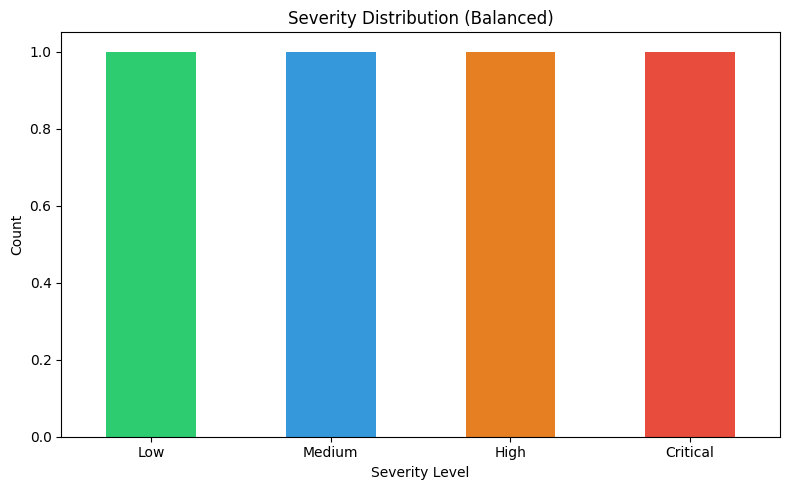

<Figure size 800x500 with 0 Axes>

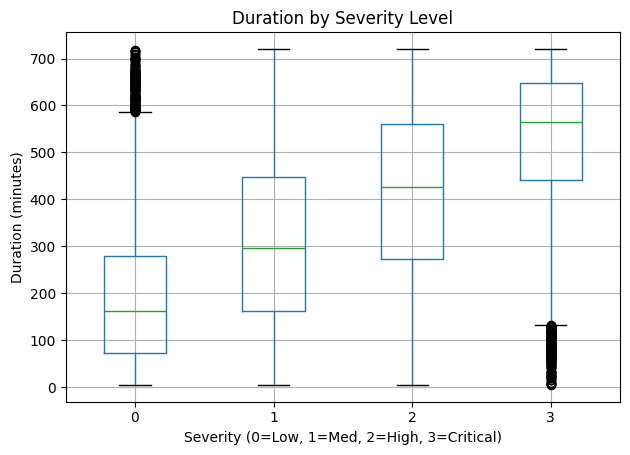

Data analysis done


In [5]:
class_names = ['Low','Medium','High','Critical']

# Plot 1: Severity distribution
plt.figure(figsize=(8,5))
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c']
pd.Series(class_names).value_counts().reindex(class_names).fillna(12500).plot(
    kind='bar', color=colors)
plt.title('Severity Distribution (Balanced)')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('severity_distribution.png', dpi=150)
plt.show()

# Plot 2: Duration by severity
plt.figure(figsize=(8,5))
df.boxplot(column='duration_minutes', by='severity_new')
plt.title('Duration by Severity Level')
plt.suptitle('')
plt.xlabel('Severity (0=Low, 1=Med, 2=High, 3=Critical)')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.savefig('duration_by_severity.png', dpi=150)
plt.show()
print("Data analysis done")

Scale & Feature Selection

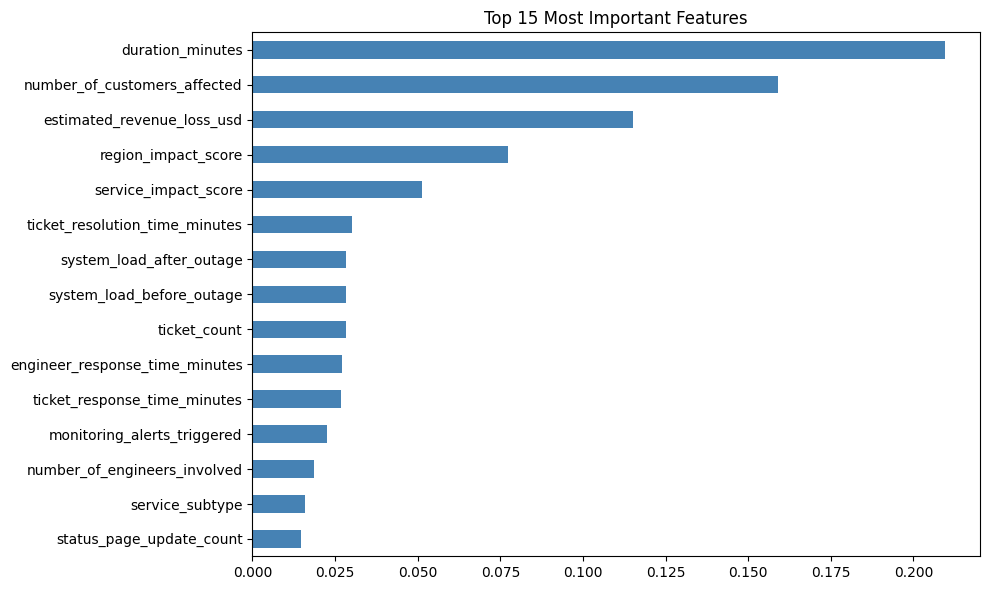

Feature selection done


In [6]:
X = df.drop('severity_new', axis=1)
y = df['severity_new']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_scaled, y)
imp = pd.Series(rf_sel.feature_importances_, index=X.columns)
top15 = imp.nlargest(15)

top15.sort_values().plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

X_best = X_scaled[top15.index]
print("Feature selection done")

Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 40000 | Test: 10000


Train Models

In [8]:
class_names = ['Low','Medium','High','Critical']

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=15,
                                                   random_state=42, n_jobs=-1)
}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': round(acc,4), 'F1-Score': round(f1,4)}
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))


Training Logistic Regression...
  Accuracy: 0.9959 | F1: 0.9959
              precision    recall  f1-score   support

         Low       1.00      0.99      1.00      2500
      Medium       0.99      1.00      0.99      2500
        High       0.99      1.00      0.99      2500
    Critical       1.00      1.00      1.00      2500

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Training Decision Tree...
  Accuracy: 0.8006 | F1: 0.8020
              precision    recall  f1-score   support

         Low       0.89      0.85      0.87      2500
      Medium       0.71      0.75      0.73      2500
        High       0.72      0.74      0.73      2500
    Critical       0.89      0.86      0.88      2500

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000


Train

Compare Models

                     Accuracy  F1-Score
Logistic Regression    0.9959    0.9959
Decision Tree          0.8006    0.8020
Random Forest          0.8778    0.8789


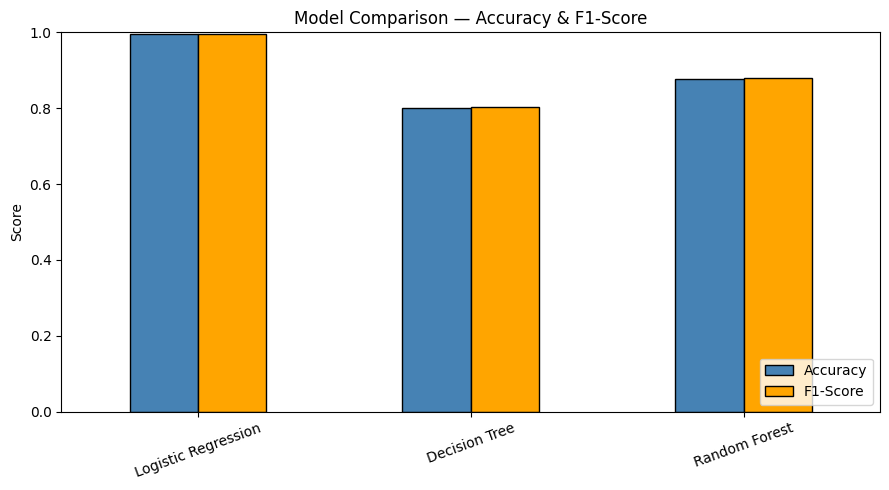

In [9]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind='bar', figsize=(9,5), ylim=(0,1),
                color=['steelblue','orange'], edgecolor='black')
plt.title('Model Comparison — Accuracy & F1-Score')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

Confusion Matrices

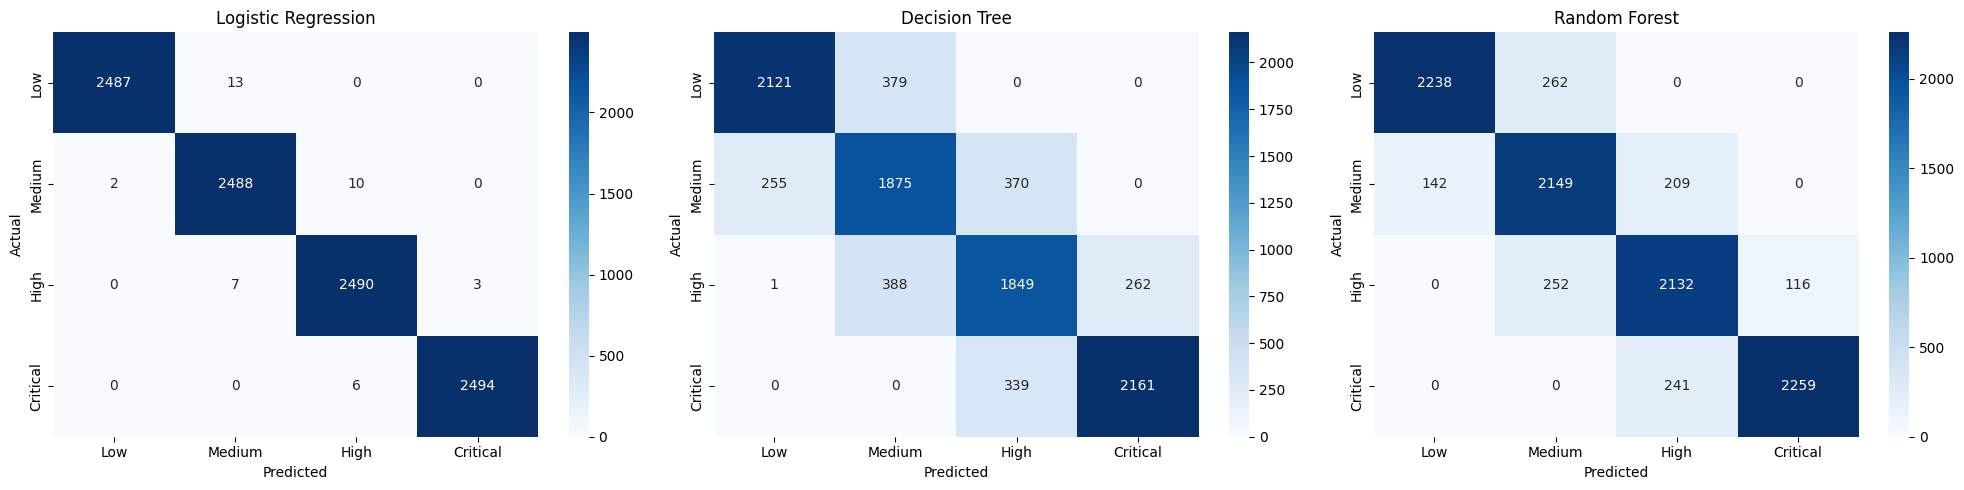

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

Download Files

In [11]:
from google.colab import files
for f in ['severity_distribution.png','duration_by_severity.png',
          'feature_importance.png','model_comparison.png',
          'confusion_matrices.png']:
    files.download(f)
print("All downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded
